In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import shap
import json
import networkx as nx
import seaborn as sns
import lingam
import warnings

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from typing import Dict
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import ccf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.api import VAR
from scipy import stats


from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report
)


warnings.filterwarnings('ignore')
print("✅ Imports loaded successfully!")

✅ Imports loaded successfully!


<br> <br>

### Read Causal graph file

In [2]:
with open("../../causality_graph/azure_pm/machine_98/structured_adjacency.json", "r") as f:
    structured_adjacency = json.load(f)

print(f"Loaded {len(structured_adjacency)} edges from structured_adjacency.json")

Loaded 774 edges from structured_adjacency.json


In [3]:
structured_adjacency[0:2]

[{'source_feature': 'volt',
  'target_feature': 'volt_lag_1h',
  'effect_strength': 0.01031322375254026},
 {'source_feature': 'volt',
  'target_feature': 'volt_lag_24h',
  'effect_strength': 0.13918872976475608}]

<br> <br> <br>

### Read the the .csv file

In [4]:
lag_features_path = "../../data/azure_pm/lag_features/machine_98_lag_features.csv"
df_machine_98 = pd.read_csv(lag_features_path)
print(f"Loaded shape: {df_machine_98.shape}")
df_machine_98.head()

Loaded shape: (8757, 65)


,datetime,volt,rotate,pressure,vibration,errorID,comp,failure,target,volt_lag_1h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,2015-01-01 06:00:00,0.303137,0.604476,0.271993,0.621000,0,0,0,0,0.000000,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
1,2015-01-01 07:00:00,0.455312,0.635538,0.480756,0.645421,0,0,0,0,0.303137,...,0.0,0.0,0.0,0.0,7,3,0,0,1,1
2,2015-01-01 08:00:00,0.449470,0.540973,0.427196,0.356126,0,0,0,0,0.455312,...,0.0,0.0,0.0,0.0,8,3,0,1,2,2
3,2015-01-01 09:00:00,0.408248,0.687752,0.378658,0.254123,0,0,0,0,0.449470,...,0.0,0.0,0.0,0.0,9,3,0,1,3,3
4,2015-01-01 10:00:00,0.486041,0.518746,0.454206,0.351050,0,0,0,0,0.408248,...,0.0,0.0,0.0,0.0,10,3,0,1,4,4


In [5]:
df_machine_98.drop(columns=["datetime", "failure", "errorID"])

,volt,rotate,pressure,vibration,comp,target,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,0.303137,0.604476,0.271993,0.621000,0,0,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,6,3,0,0,0,0
1,0.455312,0.635538,0.480756,0.645421,0,0,0.303137,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,7,3,0,0,1,1
2,0.449470,0.540973,0.427196,0.356126,0,0,0.455312,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,8,3,0,1,2,2
3,0.408248,0.687752,0.378658,0.254123,0,0,0.449470,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,9,3,0,1,3,3
4,0.486041,0.518746,0.454206,0.351050,0,0,0.408248,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,10,3,0,1,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8752,0.578128,0.640681,0.390571,0.357513,0,0,0.267632,0.686530,0.544128,0.582918,...,0.0,0.0,0.0,0.0,2,3,0,0,116,76
8753,0.327834,0.639340,0.339816,0.484520,0,0,0.578128,0.194512,0.554888,0.446084,...,0.0,0.0,0.0,0.0,3,3,0,0,117,77
8754,0.578074,0.607038,0.513075,0.416149,0,0,0.327834,0.381298,0.408099,0.516699,...,0.0,0.0,0.0,0.0,4,3,0,0,118,78
8755,0.526413,0.539851,0.582220,0.495210,0,0,0.578074,0.428880,0.601410,0.485337,...,0.0,0.0,0.0,0.0,5,3,0,0,119,79


<br> <br>

### Read ML models

In [6]:
model_dir = "../../model/azure_pm/machine_98"
pkl_files = glob.glob(os.path.join(model_dir, "*.pkl"))

models = {}
for file_path in pkl_files:
    model_name = os.path.splitext(os.path.basename(file_path))[0]
    with open(file_path, "rb") as f:
        models[model_name] = pickle.load(f)

print(f"Loaded {len(models)} models: {list(models.keys())}")

Loaded 4 models: ['CatBoost', 'LightGBM', 'RandomForest', 'XGBoost']


<br> <br>

#### Generate a random row

In [7]:
def get_random_nonzero_target_row(df):
    filtered = df[df["target"] != 0]
    if filtered.empty:
        return None
    return filtered.sample(n=1, random_state=np.random.randint(0, 10000)).iloc[0]


<br> <br>

#### Get top n rows using SHAP

In [8]:
def get_top_n_shap_features(random_row, model_dict, top_n=10):
    model = model_dict['model']
    feature_names = model_dict['feature_names']

    # Prepare the row as a DataFrame for SHAP and ensure numeric types
    X_row = random_row.to_frame().T[feature_names]
    X_row = X_row.apply(pd.to_numeric, errors='coerce')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_row)

    if isinstance(shap_values, list):
        shap_abs = np.sum([np.abs(sv).reshape(-1) for sv in shap_values], axis=0)
    else:
        shap_abs = np.abs(shap_values).reshape(-1)

    min_len = min(len(feature_names), len(shap_abs))
    df_shap = pd.DataFrame({
        'feature_name': feature_names[:min_len],
        'feature_importance': shap_abs[:min_len]
    }).sort_values('feature_importance', ascending=False).head(top_n).reset_index(drop=True)

    return df_shap

<br> <br> <br>

#### Run the random row generation method

In [9]:
# Example usage:
random_row = get_random_nonzero_target_row(df_machine_98)
random_row.drop(["datetime", "failure", "target"], inplace=True)
# random_row.apply(pd.to_numeric)
display(random_row.to_frame().T)

,volt,rotate,pressure,vibration,errorID,comp,volt_lag_1h,volt_lag_6h,volt_lag_12h,volt_lag_24h,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
5728,0.54714,0.394936,0.258364,0.462669,0,0,0.530954,0.557472,0.681644,0.463233,...,5.0,5.0,0.0,0.0,7,3,0,0,338,1


<br> <br> 

#### Run the SHAP query

In [10]:
my_models = {
    "catboost_model": 'CatBoost', 
    "lightgbm_model": 'LightGBM', 
    "randomforest_model": 'RandomForest', 
    "xgboost_model": 'XGBoost'
}

# model = models["XGBoost"]
model = models[my_models["catboost_model"]]
# model = models[my_models["lightgbm_model"]]
# model = models[my_models["randomforest_model"]]
# model = models[my_models["xgboost_model"]]
# model



,feature_name,feature_importance
0,volt_max_24h,0.138763
1,hours_since_error,0.131782


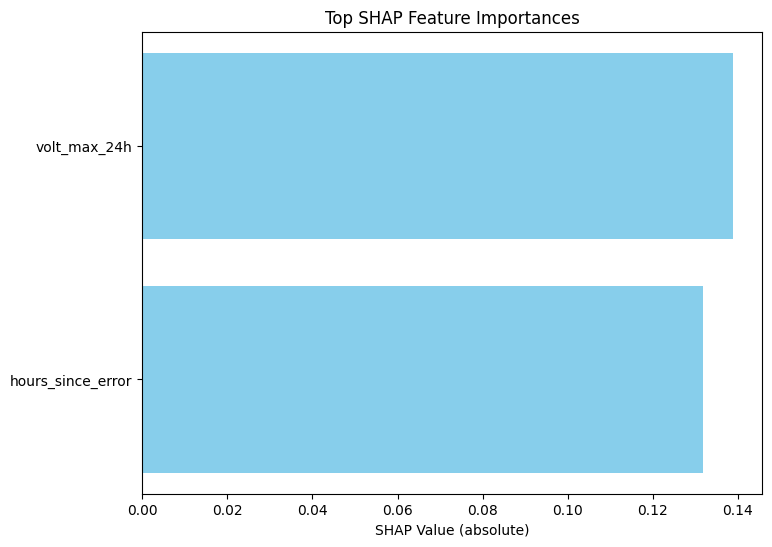

In [28]:
df_shap = get_top_n_shap_features(random_row=random_row, model_dict=model, top_n=2)
display(df_shap)


# Visualize SHAP values from df_shap as a horizontal bar plot
plt.figure(figsize=(8, 6))
plt.barh(df_shap['feature_name'][::-1], df_shap['feature_importance'][::-1], color='skyblue')
plt.xlabel('SHAP Value (absolute)')
plt.title('Top SHAP Feature Importances')
plt.show()

<br> <br> <br>

#### Map the top n SHAP to causal graph - Simple visualization

In [21]:
def visualize_and_json_shap_causal(df_shap, structured_adjacency):
    """
    Visualize the subgraph of the causal graph containing top SHAP features and return the subgraph as JSON.

    Args:
        df_shap (pd.DataFrame): DataFrame with a 'feature_name' column.
        structured_adjacency (list): List of dicts with 'source_feature' and 'target_feature' keys.

    Returns:
        str: JSON string of the subgraph.
    """
    import matplotlib.pyplot as plt
    import networkx as nx
    import json

    top_features = set(df_shap["feature_name"])
    sub_edges = []
    for edge in structured_adjacency:
        if (edge["source_feature"] in top_features) or (edge["target_feature"] in top_features):
            sub_edges.append((edge["source_feature"], edge["target_feature"]))

    G = nx.DiGraph()
    G.add_edges_from(sub_edges)

    node_colors = ['orange' if node in top_features else 'skyblue' for node in G.nodes()]
    edge_colors = ['red' if (u in top_features and v in top_features) else 'gray' for u, v in G.edges()]

    # Use graphviz_layout if available for better readability, else fallback to spring_layout
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except Exception:
        pos = nx.spring_layout(G, seed=42, k=0.8, iterations=200)

    plt.figure(figsize=(max(12, len(G.nodes()) * 0.7), max(8, len(G.nodes()) * 0.5)))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=1400,
        font_size=11,
        arrowsize=22,
        linewidths=2,
        font_weight='bold'
    )
    plt.title("Subgraph: Top SHAP Features in Causal Graph", fontsize=16)
    plt.tight_layout()
    plt.show()

    subgraph_json = {
        "nodes": [
            {"id": node, "highlight": node in top_features}
            for node in G.nodes()
        ],
        "edges": [
            {
                "source": u,
                "target": v,
                "highlight": (u in top_features and v in top_features)
            }
            for u, v in G.edges()
        ]
    }
    return json.dumps(subgraph_json, indent=2)



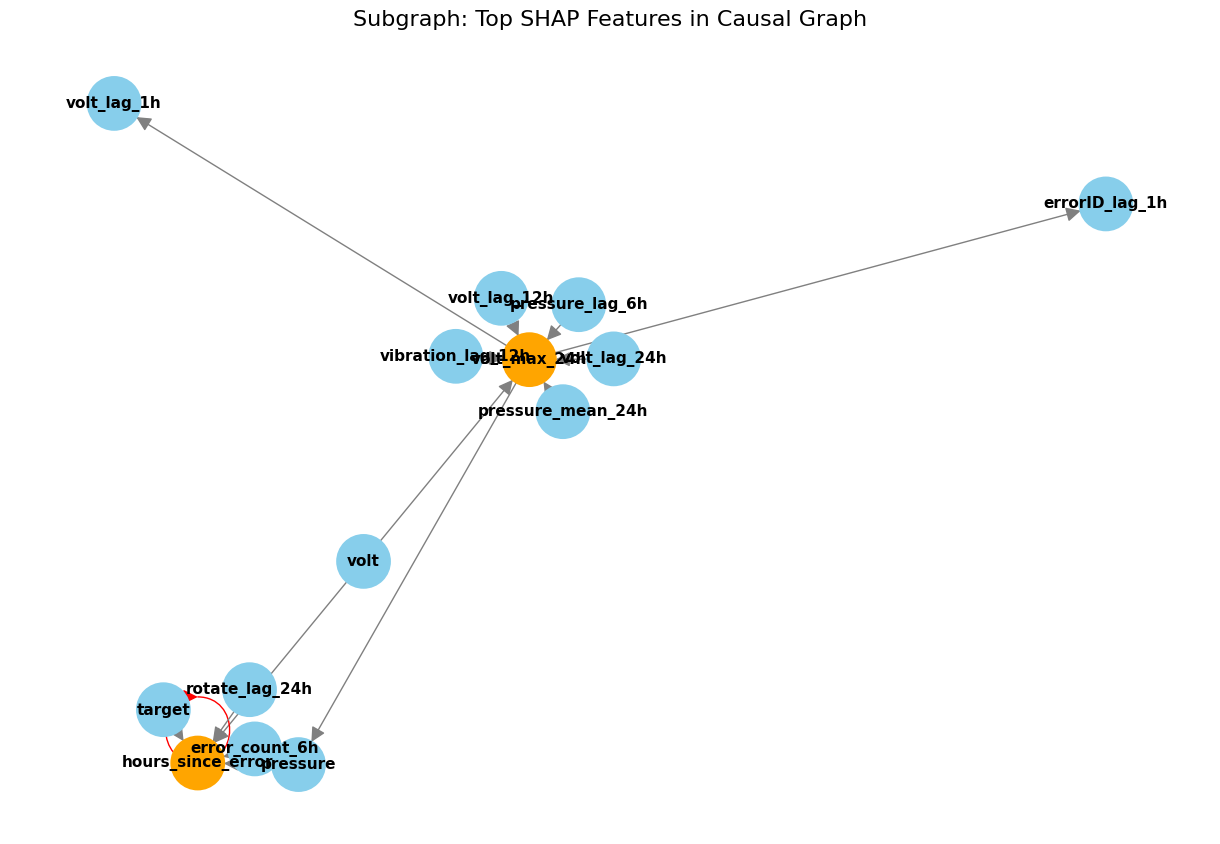

In [29]:
# Example usage:
result = visualize_and_json_shap_causal(df_shap, structured_adjacency)

<br> <br> <br>

## Visualize The subgraph - Advanced Visualization

Mapping the features from SHAP to the Causal graph that is built base don the whole dataset

In [14]:
def create_interactive_visualization(df_shap, structured_adjacency, top_n_sub_nodes=None, filename="interactive_causal_graph.html", width="100%", height="1000px"):
    """
    Creates an interactive HTML visualization of the causal graph containing top SHAP features.
    
    This version includes the top_n_sub_nodes filtering logic and creates an interactive visualization
    using pyvis instead of matplotlib.

    Args:
        df_shap (pd.DataFrame): DataFrame with a 'feature_name' column identifying the core features.
        structured_adjacency (list): List of dicts with 'source_feature', 'target_feature', 
                                     and 'effect_strength' keys.
        top_n_sub_nodes (int, optional): The number of top related nodes to include in the graph,
                                         ranked by absolute effect_strength. If None, all directly
                                         connected nodes are included. Defaults to None.
        filename (str): The name of the output HTML file. Defaults to "interactive_causal_graph.html".
        width (str): Width of the visualization. Defaults to "100%".
        height (str): Height of the visualization. Defaults to "1000px".
    
    Returns:
        str: JSON string of the subgraph (same as original function).
    """
    import networkx as nx
    import json
    import pandas as pd
    from pyvis.network import Network

    top_features = set(df_shap["feature_name"])
    
    # Store original effect strengths for JSON output
    edge_strengths = {}
    
    # If top_n_sub_nodes is specified, filter to the most influential neighbors
    if top_n_sub_nodes is not None and isinstance(top_n_sub_nodes, int) and top_n_sub_nodes >= 0:
        # 1. Identify all sub-nodes connected to top_features and rank them by effect strength
        sub_node_strengths = {}
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            strength = abs(edge.get("effect_strength", 0))  # Use absolute strength for ranking

            # Find sub-nodes (nodes not in top_features) connected to top_features
            if source in top_features and target not in top_features:
                sub_node = target
                sub_node_strengths[sub_node] = max(sub_node_strengths.get(sub_node, 0), strength)
            elif target in top_features and source not in top_features:
                sub_node = source
                sub_node_strengths[sub_node] = max(sub_node_strengths.get(sub_node, 0), strength)
        
        # 2. Select the top N sub-nodes
        sorted_sub_nodes = sorted(sub_node_strengths.items(), key=lambda item: item[1], reverse=True)
        top_sub_nodes_set = {node for node, strength in sorted_sub_nodes[:top_n_sub_nodes]}
        
        # 3. The final set of nodes to display includes top features and the selected top sub-nodes
        allowed_nodes = top_features.union(top_sub_nodes_set)
        
        # 4. Filter edges where both source and target are in our allowed set
        sub_edges = []
        edge_labels = {}
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            if source in allowed_nodes and target in allowed_nodes:
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
    else:
        # Original logic: include all nodes directly connected to any top_feature
        sub_edges = []
        edge_labels = {}
        for edge in structured_adjacency:
            if (edge["source_feature"] in top_features) or (edge["target_feature"] in top_features):
                source, target = edge["source_feature"], edge["target_feature"]
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value

    # Create NetworkX graph
    G = nx.DiGraph()
    G.add_edges_from(sub_edges)
    
    # Add edge labels as attributes to the graph
    for (u, v), label in edge_labels.items():
        if G.has_edge(u, v):
            G.edges[u, v]['label'] = label

    # If the graph is empty, return an empty JSON and skip visualization
    if not G.nodes():
        print("Warning: The resulting graph is empty. No relationships found based on the criteria.")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Create interactive visualization using pyvis
    print(f"Creating interactive visualization with {len(G.nodes())} nodes and {len(G.edges())} edges...")
    
    net = Network(height=height, width=width, notebook=False, directed=True, cdn_resources='in_line')

    # Set physics options for better layout and interactivity
    net.set_options("""
    var options = {
      "physics": {
        "enabled": true,
        "repulsion": { 
          "centralGravity": 0.2, 
          "springLength": 200, 
          "nodeDistance": 300,
          "damping": 0.1
        },
        "minVelocity": 0.75,
        "solver": "repulsion",
        "timestep": 0.22,
        "stabilization": {"iterations": 150}
      },
      "edges": {
        "arrows": {
          "to": {"enabled": true, "scaleFactor": 1.5}
        },
        "smooth": {
          "enabled": true,
          "type": "continuous"
        }
      },
      "interaction": {
        "dragNodes": true,
        "dragView": true,
        "zoomView": true,
        "selectConnectedEdges": true,
        "hover": true,
        "multiselect": true,
        "keyboard": {
          "enabled": true
        }
      },
      "manipulation": {
        "enabled": false
      }
    }
    """)

    # Add nodes to the pyvis network with enhanced interactivity
    for node in G.nodes():
        is_top = node in top_features
        net.add_node(
            node, 
            label=node, 
            color='orange' if is_top else 'skyblue',
            shape='box', 
            shadow=True, 
            font={'size': 18, 'color': 'black', 'strokeWidth': 2, 'strokeColor': 'white'},
            size=25,
            borderWidth=2,
            borderWidthSelected=4,
            title=f"{'🎯 Top SHAP Feature' if is_top else '🔗 Related Feature'}: {node}<br/>Click and drag to move!"  # Enhanced tooltip
        )

    # Add edges to the pyvis network with enhanced styling
    for u, v in G.edges():
        label = G.edges[u, v].get('label', '')
        is_highlight = (u in top_features and v in top_features)
        net.add_edge(
            u, v, 
            label=label, 
            color='red' if is_highlight else 'gray',
            width=4 if is_highlight else 2,
            title=f"📊 Effect strength: {label}<br/>From: {u} → To: {v}",  # Enhanced tooltip
            font={'size': 12, 'color': 'blue', 'strokeWidth': 1, 'strokeColor': 'white'}
        )

    # Generate and save HTML content with proper encoding
    html_content = net.generate_html()
    try:
        with open(filename, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"[SUCCESS] Interactive graph saved to '{filename}'. Open this file in your browser.")
    except Exception as e:
        print(f"[ERROR] Could not save the HTML file. Reason: {e}")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Generate JSON output (same as original function)
    subgraph_json = {
        "nodes": [
            {"id": node, "highlight": node in top_features}
            for node in G.nodes()
        ],
        "edges": [
            {
                "source": u,
                "target": v,
                "highlight": (u in top_features and v in top_features),
                "effect_strength": edge_strengths.get((u, v), 0.0)  # Use original numeric value
            }
            for u, v in G.edges()
        ]
    }
    
    return json.dumps(subgraph_json, indent=2)


In [30]:
# Default larger size (1000px height)
# result = create_interactive_visualization(df_shap, structured_adjacency, top_n_sub_nodes=7)

# Custom large size
# result = create_interactive_visualization(df_shap, structured_adjacency, top_n_sub_nodes=7, width="1400px", height="1200px")

# Full screen
result = create_interactive_visualization(df_shap, structured_adjacency, top_n_sub_nodes=None, width="100vw", height="100vh")

Creating interactive visualization with 14 nodes and 15 edges...
[SUCCESS] Interactive graph saved to 'interactive_causal_graph.html'. Open this file in your browser.



<br> <br> <br>

## Visualize The subgraph - Advanced Visualization - Target included


In [34]:
def create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=None, filename="interactive_causal_graph.html", width="100%", height="1000px"):
    """
    Creates an interactive HTML visualization of the causal graph containing top SHAP features.
    
    This version includes the top_n_sub_nodes filtering logic and creates an interactive visualization
    using pyvis instead of matplotlib.

    Args:
        df_shap (pd.DataFrame): DataFrame with a 'feature_name' column identifying the core features.
        structured_adjacency (list): List of dicts with 'source_feature', 'target_feature', 
                                     and 'effect_strength' keys.
        top_n_sub_nodes (int, optional): The number of top related nodes to include in the graph,
                                         ranked by absolute effect_strength. If None, all directly
                                         connected nodes are included. Defaults to None.
        filename (str): The name of the output HTML file. Defaults to "interactive_causal_graph.html".
        width (str): Width of the visualization. Defaults to "100%".
        height (str): Height of the visualization. Defaults to "1000px".
    
    Returns:
        str: JSON string of the subgraph (same as original function).
    """
    import networkx as nx
    import json
    import pandas as pd
    from pyvis.network import Network

    top_features = set(df_shap["feature_name"])
    target_variable = 'target'  # Define the target variable name
    
    # Store original effect strengths for JSON output
    edge_strengths = {}
    
    # If top_n_sub_nodes is specified, filter to the most influential relationships
    if top_n_sub_nodes is not None and isinstance(top_n_sub_nodes, int) and top_n_sub_nodes >= 0:
        # 1. Find all edges connecting top_features to other nodes (sub-nodes), excluding target
        relevant_edges = []
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            strength = abs(edge.get("effect_strength", 0))  # Use absolute strength for ranking
            
            # Find relationships where one node is in top_features and the other is not (excluding target variable)
            if source in top_features and target not in top_features and target != target_variable:
                relevant_edges.append({
                    'top_feature': source,
                    'sub_node': target,
                    'strength': strength,
                    'original_edge': edge
                })
            elif target in top_features and source not in top_features and source != target_variable:
                relevant_edges.append({
                    'top_feature': target,
                    'sub_node': source,
                    'strength': strength,
                    'original_edge': edge
                })
        
        # 2. Sort all relationships by effect strength and select top N
        sorted_relationships = sorted(relevant_edges, key=lambda x: x['strength'], reverse=True)
        top_relationships = sorted_relationships[:top_n_sub_nodes]
        
        # 3. Get the set of sub-nodes from top N relationships
        top_sub_nodes_set = {rel['sub_node'] for rel in top_relationships}
        
        print(f"Selected top {len(top_relationships)} relationships with sub-nodes: {top_sub_nodes_set}")
        for i, rel in enumerate(top_relationships, 1):
            print(f"  {i}. {rel['top_feature']} ↔ {rel['sub_node']} (strength: {rel['strength']:.4f})")
        
        # 4. The final set of nodes includes top features, selected sub-nodes, AND target variable
        allowed_nodes = top_features.union(top_sub_nodes_set).union({target_variable})
        
        # 5. Filter edges where both source and target are in our allowed set
        sub_edges = []
        edge_labels = {}
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            if source in allowed_nodes and target in allowed_nodes:
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
    else:
        # Original logic: include all nodes directly connected to any top_feature, PLUS target variable
        sub_edges = []
        edge_labels = {}
        allowed_nodes = set()
        
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            # Include edges connected to top_features OR target variable
            if (source in top_features) or (target in top_features) or (source == target_variable) or (target == target_variable):
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
                allowed_nodes.add(source)
                allowed_nodes.add(target)

    # Create NetworkX graph
    G = nx.DiGraph()
    G.add_edges_from(sub_edges)
    
    # Add edge labels as attributes to the graph
    for (u, v), label in edge_labels.items():
        if G.has_edge(u, v):
            G.edges[u, v]['label'] = label

    # If the graph is empty, return an empty JSON and skip visualization
    if not G.nodes():
        print("Warning: The resulting graph is empty. No relationships found based on the criteria.")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Create interactive visualization using pyvis
    print(f"Creating interactive visualization with {len(G.nodes())} nodes and {len(G.edges())} edges...")
    
    net = Network(height=height, width=width, notebook=False, directed=True, cdn_resources='in_line')

    # Set physics options for better layout and interactivity
    net.set_options("""
    var options = {
      "physics": {
        "enabled": true,
        "repulsion": { 
          "centralGravity": 0.2, 
          "springLength": 200, 
          "nodeDistance": 300,
          "damping": 0.1
        },
        "minVelocity": 0.75,
        "solver": "repulsion",
        "timestep": 0.22,
        "stabilization": {"iterations": 150}
      },
      "edges": {
        "arrows": {
          "to": {"enabled": true, "scaleFactor": 1.5}
        },
        "smooth": {
          "enabled": true,
          "type": "continuous"
        }
      },
      "interaction": {
        "dragNodes": true,
        "dragView": true,
        "zoomView": true,
        "selectConnectedEdges": true,
        "hover": true,
        "multiselect": true,
        "keyboard": {
          "enabled": true
        }
      },
      "manipulation": {
        "enabled": false
      }
    }
    """)

    # Add nodes to the pyvis network with enhanced interactivity
    for node in G.nodes():
        is_top = node in top_features
        is_target = node == target_variable  
        
        # Determine node styling based on type
        if is_target:
            color = 'red'
            node_type = '🎯 TARGET VARIABLE'
            size = 35  # Larger size for target
        elif is_top:
            color = 'orange'
            node_type = '⭐ Top SHAP Feature'
            size = 25
        else:
            color = 'skyblue'
            node_type = '🔗 Related Feature'
            size = 20
            
        net.add_node(
            node, 
            label=node, 
            color=color,
            shape='box', 
            shadow=True, 
            font={'size': 18, 'color': 'black', 'strokeWidth': 2, 'strokeColor': 'white'},
            size=size,
            borderWidth=3 if is_target else 2,
            borderWidthSelected=5 if is_target else 4,
            title=f"{node_type}: {node}<br/>Click and drag to move!"  # Enhanced tooltip
        )

    # Add edges to the pyvis network with enhanced styling
    for u, v in G.edges():
        label = G.edges[u, v].get('label', '')
        is_highlight = (u in top_features and v in top_features)
        is_target_edge = (u == target_variable or v == target_variable)
        
        # Special styling for edges connected to target
        if is_target_edge:
            edge_color = 'darkred'
            edge_width = 5
            edge_title = f"🎯 TARGET CONNECTION - Effect strength: {label}<br/>From: {u} → To: {v}"
        elif is_highlight:
            edge_color = 'red'
            edge_width = 4
            edge_title = f"📊 SHAP-SHAP Connection - Effect strength: {label}<br/>From: {u} → To: {v}"
        else:
            edge_color = 'gray'
            edge_width = 2
            edge_title = f"📊 Effect strength: {label}<br/>From: {u} → To: {v}"
            
        net.add_edge(
            u, v, 
            label=label, 
            color=edge_color,
            width=edge_width,
            title=edge_title,  # Enhanced tooltip
            font={'size': 12, 'color': 'blue', 'strokeWidth': 1, 'strokeColor': 'white'}
        )

    # Generate and save HTML content with proper encoding
    html_content = net.generate_html()
    try:
        with open(filename, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"[SUCCESS] Interactive graph saved to '{filename}'. Open this file in your browser.")
    except Exception as e:
        print(f"[ERROR] Could not save the HTML file. Reason: {e}")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Generate JSON output (same as original function, but include target info)
    subgraph_json = {
        "nodes": [
            {
                "id": node, 
                "highlight": node in top_features,
                "is_target": node == target_variable,
                "node_type": "target" if node == target_variable else ("shap_feature" if node in top_features else "related_feature")
            }
            for node in G.nodes()
        ],
        "edges": [
            {
                "source": u,
                "target": v,
                "highlight": (u in top_features and v in top_features),
                "is_target_connection": (u == target_variable or v == target_variable),
                "effect_strength": edge_strengths.get((u, v), 0.0)  # Use original numeric value
            }
            for u, v in G.edges()
        ]
    }
    
    return json.dumps(subgraph_json, indent=2)

In [35]:
# Example usage with custom size:
# For a larger plot:
# result = create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=7, filename="large_graph.html", width="1400px", height="1200px")
# 
# For full screen:
result = create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=7, filename="fullscreen_graph_with_target.html", width="100vw", height="100vh")

Selected top 7 relationships with sub-nodes: {'vibration_lag_12h', 'volt_lag_24h', 'volt_lag_12h', 'pressure', 'volt', 'volt_lag_1h'}
  1. volt_max_24h ↔ volt (strength: 1.7520)
  2. volt_max_24h ↔ volt (strength: 1.6329)
  3. volt_max_24h ↔ volt_lag_1h (strength: 0.1130)
  4. volt_max_24h ↔ volt_lag_12h (strength: 0.0418)
  5. volt_max_24h ↔ volt_lag_24h (strength: 0.0362)
  6. volt_max_24h ↔ pressure (strength: 0.0241)
  7. volt_max_24h ↔ vibration_lag_12h (strength: 0.0107)
Creating interactive visualization with 9 nodes and 26 edges...
[SUCCESS] Interactive graph saved to 'fullscreen_graph_with_target.html'. Open this file in your browser.


<br> <br> <br>

---

<br> <br> <br>

## Counterfactual